# Netflix Movies and TV Shows - Exploratory Data Analysis (EDA)

## Objective:
The goal of this project is to explore the Netflix dataset, clean the data, visualize trends, and generate business insights using Python, Pandas, and Matplotlib.

Import Libraries

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the Dataset

In [180]:
df = pd.read_csv("netflix_titles.csv")

Initial Data Exploration

In [181]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [182]:
df.shape

(8807, 12)

In [183]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Data Cleaning

In [185]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [186]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [187]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3842,s3843,Movie,Gatao 2: Rise of the King,Yen Cheng-kuo,"Collin Chou, Jason Wang, Jack Kao, Tsai Chen-n...",Taiwan,"May 9, 2019",2018,TV-MA,126 min,"Action & Adventure, Dramas, International Movies",When a zealous gang leader plans to take out a...
2278,s2279,Movie,Mary Kom,Omung Kumar,"Priyanka Chopra, Darshan Kumar, Sunil Thapa, K...",India,"July 5, 2020",2014,TV-PG,120 min,"Dramas, International Movies, Sports Movies",The daughter of a poor rice farmer overcomes t...
8341,s8342,Movie,The Help,Tate Taylor,"Emma Stone, Viola Davis, Bryce Dallas Howard, ...",United States,"June 1, 2020",2011,PG-13,147 min,Dramas,"A young, white writer stirs up the status quo ..."
6669,s6670,Movie,Ek Hasina Thi,Sriram Raghavan,"Saif Ali Khan, Urmila Matondkar, Seema Biswas,...",India,"August 1, 2019",2004,TV-MA,134 min,"Dramas, International Movies, Thrillers",Imprisoned for underworld crimes she didn’t co...
623,s624,Movie,Mommy Issues,Jose Javier Reyes,"Pokwang, Sue Ramirez, Jerome Ponce, Ryan Bang,...",NaN,"June 30, 2021",2021,TV-MA,90 min,"Comedies, Dramas, International Movies",Close quarters and new romances add trouble to...


In [188]:
df.duplicated().sum()

np.int64(0)

In [189]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [190]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [191]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [192]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


Exploratory Data Analysis (EDA)

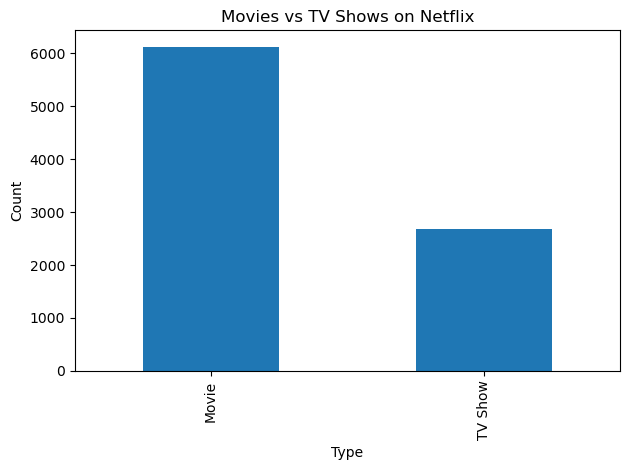

In [194]:
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../Images/movies_vs_tvshows.png", dpi=300)

plt.show()

Observation: Netflix has a significantly larger number of Movies than TV Shows in this dataset.

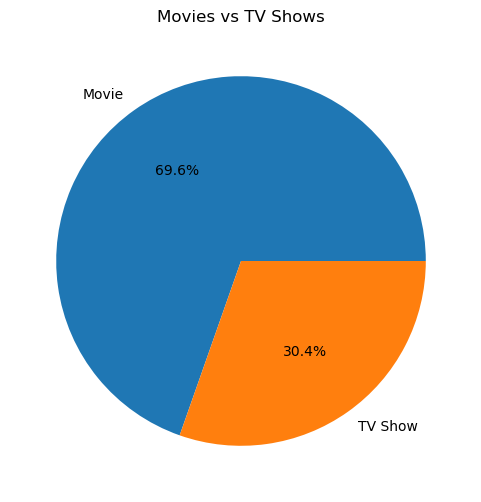

In [195]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

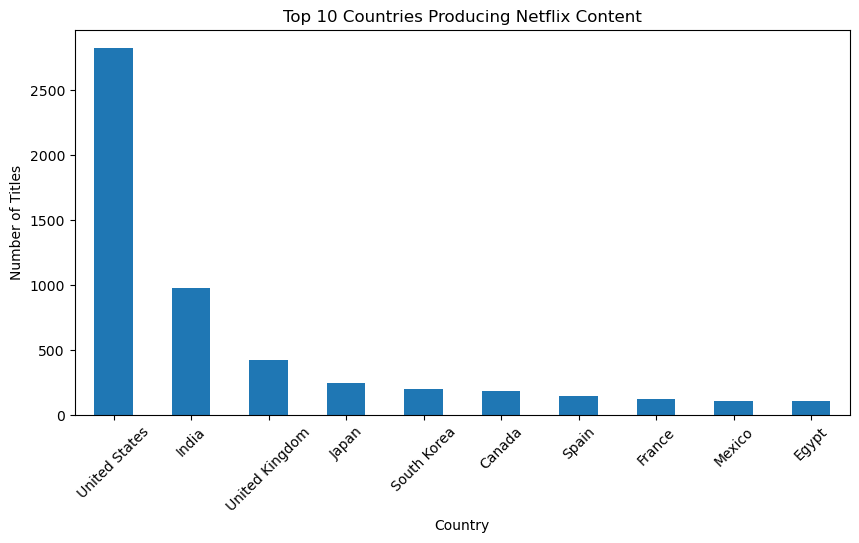

In [196]:
df["country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.savefig("../Images/top_10_countries.png", dpi=300)
plt.show()

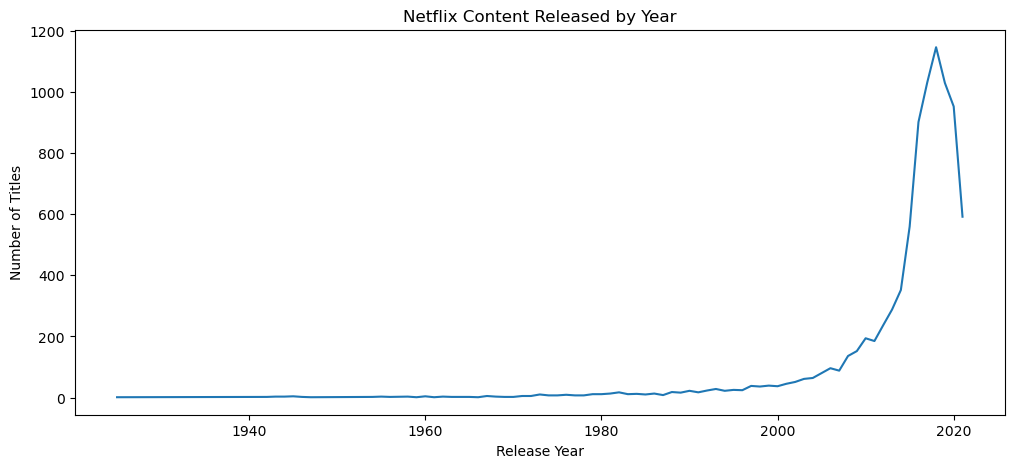

In [197]:
df["release_year"].value_counts().sort_index().plot(
    figsize=(12,5)
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.savefig("../Images/content_added_by_year.png", dpi=300)
plt.show()

Observation: The number of titles released increases substantially after 2015, indicating rapid growth in Netflix's content library during that period.

## Business Questions and Analysis

1. How many Movies and TV Shows are there?

In [198]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

2. Which are the Top 10 Genres?

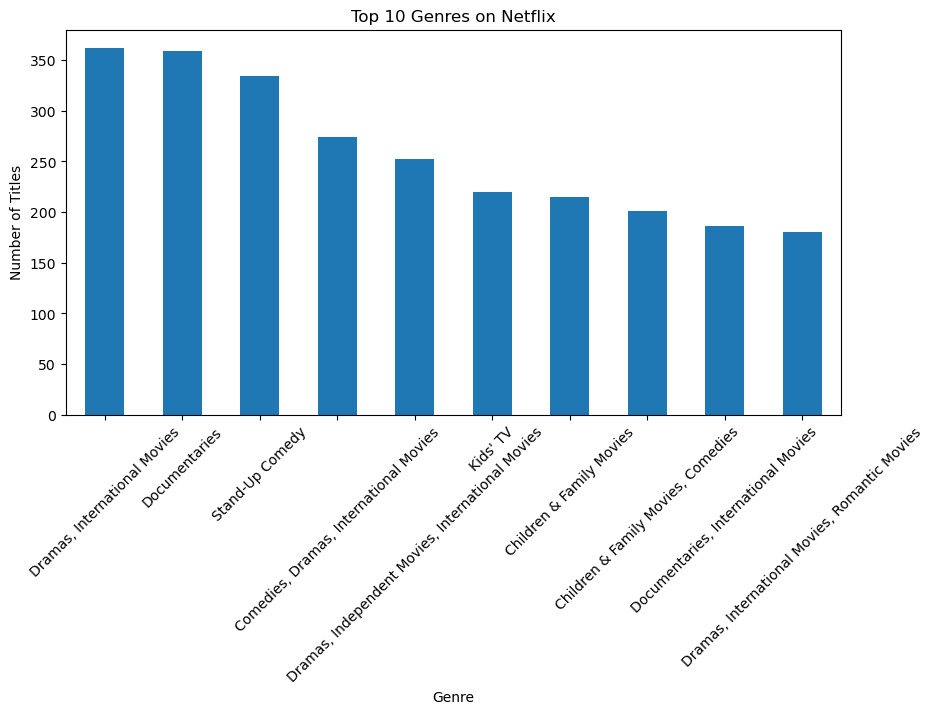

In [199]:
df["listed_in"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.savefig("../Images/genre_on_netflix.png", dpi=300)
plt.xticks(rotation=45)
plt.show()

3. Which ratings are most common?

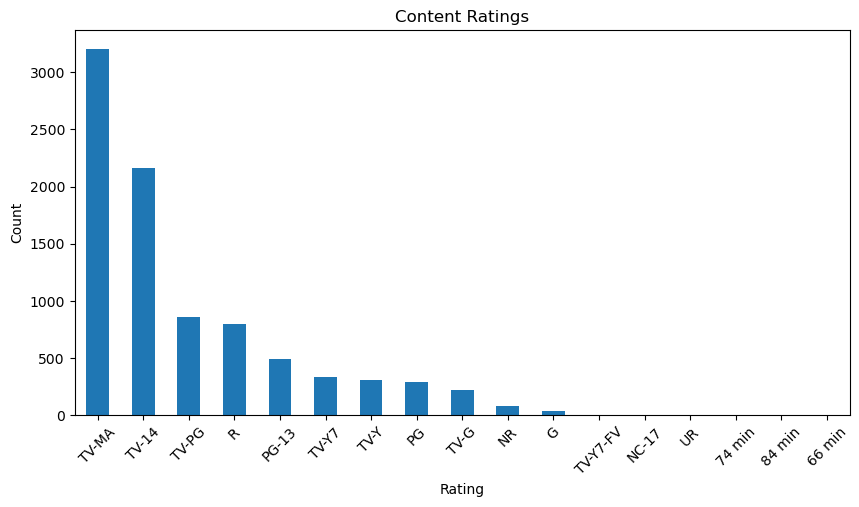

In [200]:
df["rating"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("../Images/content_rating.png", dpi=300)
plt.show()

4. Which years had the most releases?

In [201]:
df[df["release_year"] == df["release_year"].value_counts().idxmax()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,2021-09-22,2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
37,s38,TV Show,Angry Birds,NaN,"Antti Pääkkönen, Heljä Heikkinen, Lynne Guagli...",Finland,2021-09-16,2018,TV-Y7,1 Season,"Kids' TV, TV Comedies","Birds Red, Chuck and their feathered friends h..."
73,s74,Movie,King of Boys,Kemi Adetiba,"Sola Sobowale, Adesua Etomi, Remilekun ""Remini...",Nigeria,2021-09-14,2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...
94,s95,Movie,Show Dogs,Raja Gosnell,"Will Arnett, Ludacris, Natasha Lyonne, Stanley...","United Kingdom, United States",2021-09-08,2018,PG,90 min,"Children & Family Movies, Comedies",A rough and tough police dog must go undercove...
96,s97,Movie,If I Leave Here Tomorrow: A Film About Lynyrd ...,Stephen Kijak,"Ronnie Van Zandt, Gary Rossington, Allen Colli...",United States,2021-09-07,2018,TV-MA,97 min,"Documentaries, Music & Musicals","Using interviews and archival footage, this do..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8732,s8733,Movie,White Chamber,Paul Raschid,"Shauna MacDonald, Oded Fehr, Amrita Acharia, S...",United Kingdom,2019-08-01,2018,TV-MA,89 min,"Sci-Fi & Fantasy, Thrillers","When a civil war ravages the UK, a scientist a..."
8743,s8744,Movie,Wildlife,Paul Dano,"Carey Mulligan, Ed Oxenbould, Bill Camp, Jake ...",United States,2020-09-01,2018,PG-13,105 min,"Dramas, Independent Movies",A teen’s life in 1960 Montana grows complicate...
8774,s8775,Movie,يوم الدين,Abu Bakr Shawky,"Rady Gamal, Ahmed Abdelhafiz, Shahira Fahmy, S...","Egypt, Austria, United States",2019-10-22,2018,TV-14,97 min,"Dramas, Independent Movies, International Movies",A man cured of leprosy and a young orphan leav...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,2018-08-31,2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."


5. Oldest Netflix title

In [202]:
df[df["release_year"] == df["release_year"].min()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,2018-12-30,1925,TV-14,1 Season,TV Shows,This collection restores films from women who ...


6. Newest Netfilx title

In [203]:
df[df["release_year"] == df["release_year"].max()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
1468,s1469,Movie,What Happened to Mr. Cha?,Kim Dong-kyu,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,2021-01-01,2021,TV-MA,102 min,"Comedies, International Movies","With the peak of his career long behind him, a..."
1551,s1552,TV Show,Hilda,NaN,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States",2020-12-14,2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend..."
1696,s1697,TV Show,Polly Pocket,NaN,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland",2020-11-15,2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...
2920,s2921,TV Show,Love Is Blind,NaN,"Nick Lachey, Vanessa Lachey",United States,2020-02-13,2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...


In [204]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
df["day_added"] = df["date_added"].dt.day

7. Which year did Netflix add the most content?

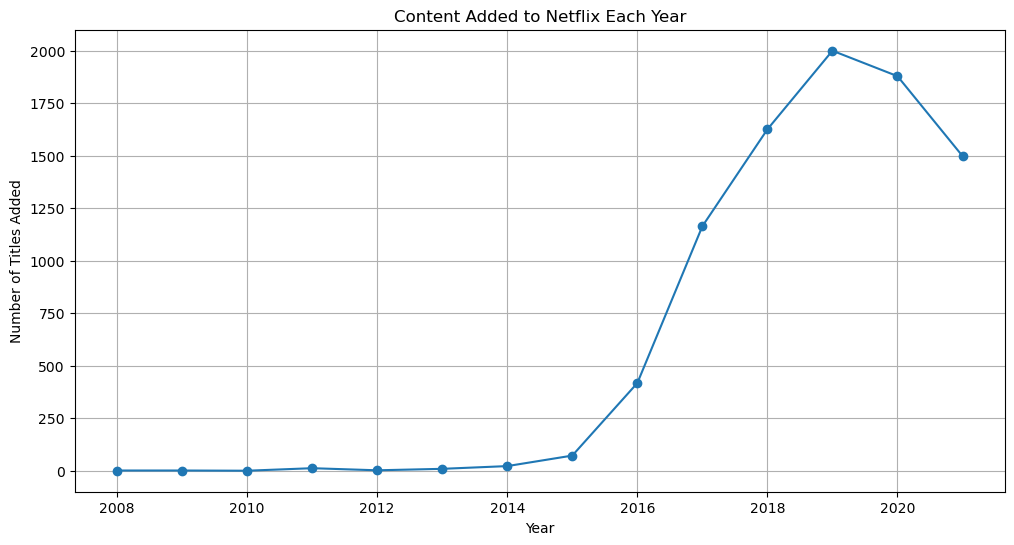

In [205]:
df["year_added"].value_counts().sort_index().plot(
    kind="line",
    figsize=(12,6),
    marker="o"
)

plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)

plt.show()

### Observation

Netflix experienced rapid growth in content additions between 2016 and 2019. After this period, the number of additions declined slightly.

8. Which month does Netflix add the most content?

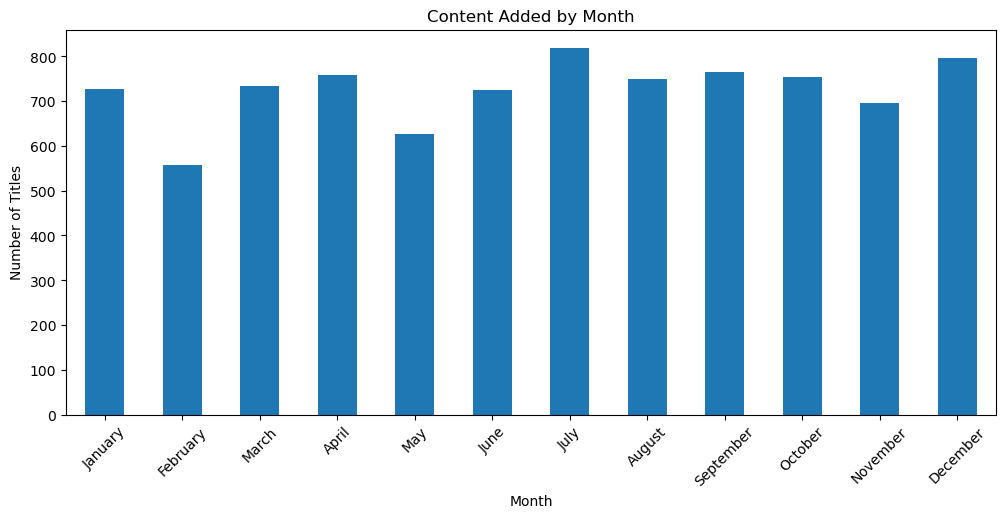

In [206]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    df["month_added"]
    .value_counts()
    .reindex(month_order)
)

monthly.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.savefig("../Images/content_added_by_month.png", dpi=300)

plt.show()

9. Who are the Top 10 Directors on Netflix?

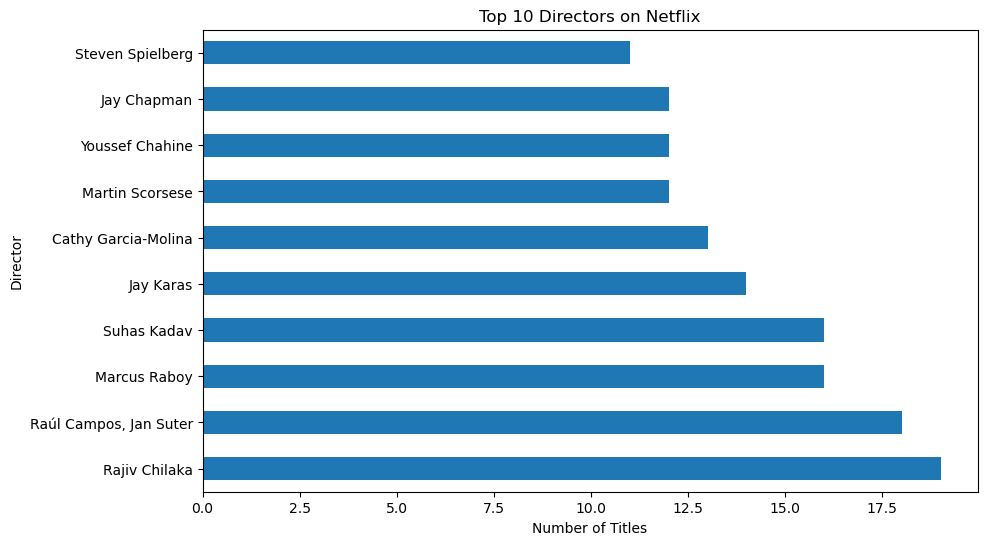

In [207]:
df["director"].value_counts().head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.savefig("../Images/top_10_directors.png", dpi=300)
plt.show()

10. Which countries produce the most Netflix content?

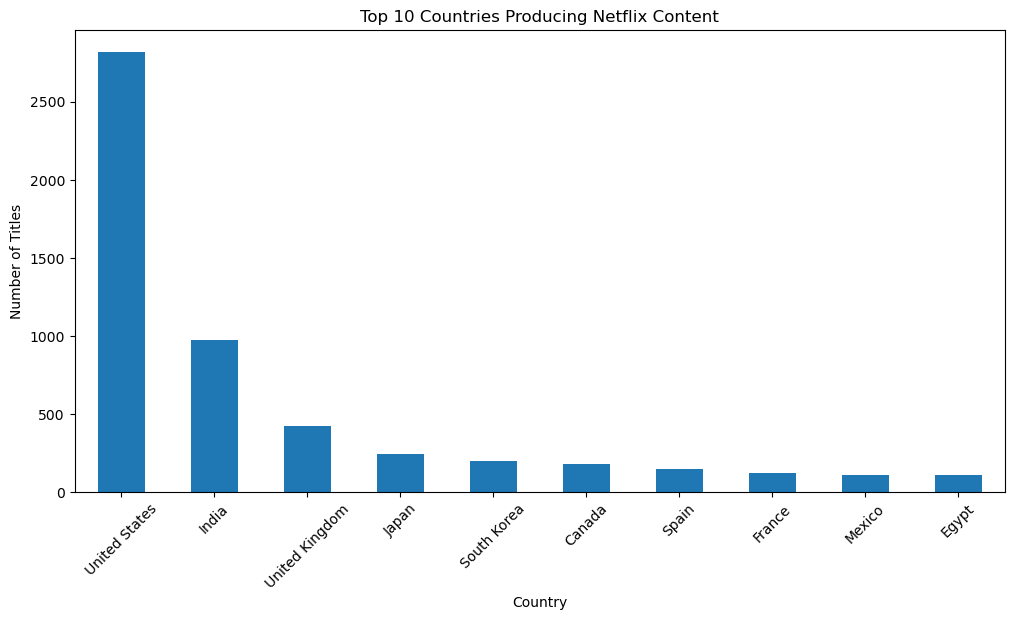

In [208]:
top_countries.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Observation

The United States contributes the largest amount of content in the Netflix dataset, followed by several other countries, highlighting Netflix's strong presence in North America while also maintaining a global content library.

# Business Insights

1. Netflix's catalog is dominated by Movies.
2. The United States contributes the highest number of titles.
3. Netflix experienced rapid content growth after 2015.
4. International Movies are among the most common genres.
5. TV-MA is one of the most common content ratings.
6. Netflix has expanded globally with content from many countries.

## 11. Conclusion

This project analyzed the Netflix Movies and TV Shows dataset using Python to uncover meaningful trends and patterns. After cleaning and exploring the data, several insights were identified through visualizations and statistical analysis.

The analysis revealed that movies make up a larger share of Netflix's content than TV shows. The number of titles added to Netflix increased significantly in recent years, with the United States contributing the highest number of titles. Drama, Comedy, and International Movies were among the most popular genres, and the ratings analysis showed that Netflix offers content for a wide range of audiences.

Overall, this project demonstrates the complete Exploratory Data Analysis (EDA) workflow, including data cleaning, feature engineering, visualization, and business insight generation. It highlights how Python libraries such as Pandas, NumPy, and Matplotlib can be used to analyze real-world datasets and support data-driven decision-making.